# **IDENTIFICATION THRESHOLD**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys

!pip install facenet-pytorch

src_path = "/content/drive/MyDrive/11/Consegna finale/src"

if src_path not in sys.path:
    sys.path.append(src_path)

import os
import torch
from sklearn.model_selection import train_test_split
from liveness_detector import SpoofingModel
from identification_system import IdentificationSystem

### **Valutazione Sistema di Identificazione (Open-Set 1:N)**

In questa sezione viene valutato lo scenario **Open-Set**, dove il sistema deve identificare un volto e decidere se appartiene a un utente iscritto o se è uno sconosciuto. Il protocollo segue tre fasi distinte per evitare Data Leakage:

1.  **Calibrazione Soglie (Validation Set 40%):**
    Si utilizzano i dati di validation per modellare la distribuzione degli "Impostori". Vengono calcolate diverse soglie di distanza (**Ti**) corrispondenti a target di **FAR (False Acceptance Rate)** specifici (es. 1%, 2%, 5%, 10%), definendo la curva operativa del sistema.

2.  **Test e Selezione Operativa (Test Set 60%):**
    Le soglie vengono applicate al Test Set per misurare le performance reali (DIR - Detection & Identification Rate).
    * Viene fissata una **Soglia Operativa (Ti)** conservativa, corrispondente a un **FAR teorico dell'1%**.
    * Si calcolano le metriche di accuratezza **Rank-1** e **Rank-2** utilizzando questa soglia.

3.  **Analisi Robustezza (Spoofing):**
    Il sistema, configurato con la soglia operativa, viene sottoposto a stress-test con un dataset di attacchi (spoof), confrontando due scenari:
    * **Scenario A (Liveness OFF):** Accesso basato esclusivamente sulla distanza biometrica (Vulnerabile se la distanza è minore della soglia **Ti**).
    * **Scenario B (Liveness ON):** Accesso a doppio controllo. L'utente viene accettato solo se supera il controllo Liveness (Score > **T_liveness**) **E** il controllo Biometrico (distanza < **Ti**).

In [ ]:
def get_probe_split_lists(probes_root_path, val_size=0.4, random_seed=42):
    """
    Funzione per splittare i dati di Probe in Validation (per calcolo soglie) e Test.
    """
    all_files = []
    all_labels = []

    if not os.path.exists(probes_root_path): return [], [], [], []

    subjects = sorted([d for d in os.listdir(probes_root_path) if os.path.isdir(os.path.join(probes_root_path, d))])

    for subject_dir in subjects:
        subject_path = os.path.join(probes_root_path, subject_dir)
        if "subject_" in subject_dir:
            try:
                label = int(subject_dir.split('_')[1])
                files = sorted([f for f in os.listdir(subject_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

                for fname in files:
                    all_files.append(os.path.join(subject_path, fname))
                    all_labels.append(label)
            except:
                continue

    if not all_files: return [], [], [], []

    X_train, X_test, y_train, y_test = train_test_split(
        all_files, all_labels,
        test_size=(1 - val_size),
        stratify=all_labels,
        random_state=random_seed
    )
    return X_train, X_test, y_train, y_test

--- Identification System Evaluation su cpu ---
Inizializzazione Modello su cpu...
ATTENZIONE: Nessun peso custom trovato/fornito. Uso VGGFace2 standard.


  0%|          | 0.00/107M [00:00<?, ?B/s]


Caricamento Gallery da file: /content/drive/MyDrive/11/11/Consegna parziale/features_labels_gr_11 e /content/drive/MyDrive/11/11/Consegna parziale/features_embeddings_gr_11...
Gallery caricata: 160 soggetti.

--- Inizio Calcolo Soglie Identification (Ti) ---
Target FARs richiesti: ['1.0%', '2.0%', '5.0%', '7.000000000000001%', '10.0%', '15.0%']
Validation Set per Ti: 143 immagini

--- RISULTATI CALCOLO SOGLIE (Validation) ---
Target FAR: 1.0% -> Soglia Ti: 0.7903
  > Valid. Actual FAR: 1.40%
  > Valid. Est. DIR:   99.30%
  > Valid. Est. FRR:   0.70%
------------------------------
Target FAR: 2.0% -> Soglia Ti: 0.7960
  > Valid. Actual FAR: 2.10%
  > Valid. Est. DIR:   100.00%
  > Valid. Est. FRR:   0.00%
------------------------------
Target FAR: 5.0% -> Soglia Ti: 0.8178
  > Valid. Actual FAR: 5.59%
  > Valid. Est. DIR:   100.00%
  > Valid. Est. FRR:   0.00%
------------------------------
Target FAR: 7.000000000000001% -> Soglia Ti: 0.8342
  > Valid. Actual FAR: 6.99%
  > Valid. Est.

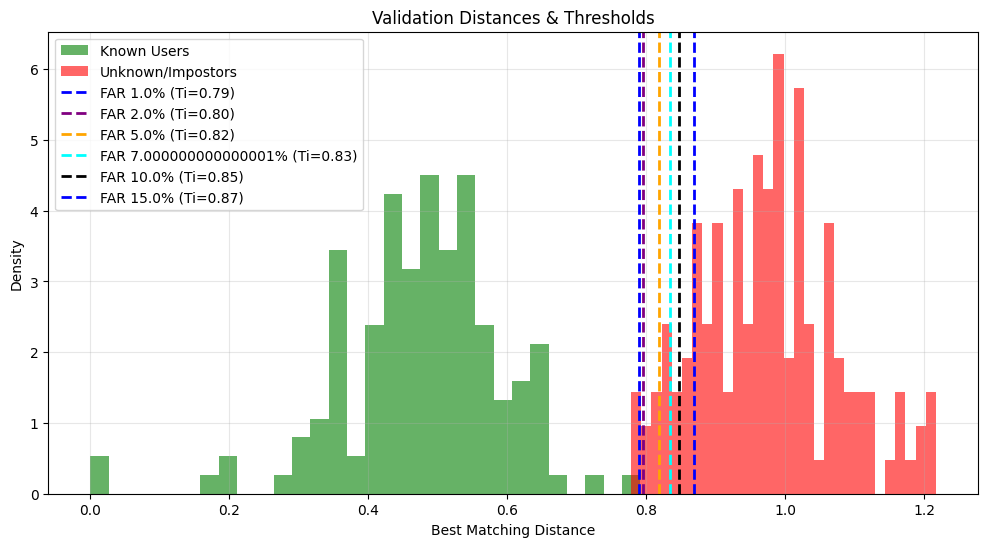


Recupero Test Set per Identificazione...

--- VALUTAZIONE TEST SET MULTIPLA (Open-Set) ---
Numero thresholds da testare: 6
Target FAR: 1.0% | Soglia Ti: 0.7903
  [Known]   DIR: 99.54% | FRR: 0.46%
  [Unknown] TNR: 100.00% | FAR: 0.00%
--------------------------------------------------
Target FAR: 2.0% | Soglia Ti: 0.7960
  [Known]   DIR: 99.54% | FRR: 0.46%
  [Unknown] TNR: 99.54% | FAR: 0.46%
--------------------------------------------------
Target FAR: 5.0% | Soglia Ti: 0.8178
  [Known]   DIR: 99.54% | FRR: 0.46%
  [Unknown] TNR: 99.07% | FAR: 0.93%
--------------------------------------------------
Target FAR: 7.000000000000001% | Soglia Ti: 0.8342
  [Known]   DIR: 99.54% | FRR: 0.46%
  [Unknown] TNR: 96.30% | FAR: 3.70%
--------------------------------------------------
Target FAR: 10.0% | Soglia Ti: 0.8465
  [Known]   DIR: 99.54% | FRR: 0.46%
  [Unknown] TNR: 94.91% | FAR: 5.09%
--------------------------------------------------
Target FAR: 15.0% | Soglia Ti: 0.8695
  [Known]   

In [ ]:
PATH_GALLERY_EMB_PREFIX = "/content/drive/MyDrive/11/11/Consegna parziale/features_embeddings_gr_11"
PATH_GALLERY_LBL_PREFIX = "/content/drive/MyDrive/11/11/Consegna parziale/features_labels_gr_11"
PATH_PROBES_DIR = "/content/drive/MyDrive/BBA_Dataset_processed/probes"

PATH_SPOOF_DIR = "/content/drive/MyDrive/Spoof_finale/test/spoof"

PATH_LIVENESS_MODEL = "/content/drive/MyDrive/11/11/Consegna parziale/models/best_weights_spoof_gr_11.pth"

THRESHOLD_LIVENESS_TF = 0.6459

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--- Identification System Evaluation su {device} ---")

id_system = IdentificationSystem(device)

if os.path.exists(f"{PATH_GALLERY_EMB_PREFIX}.npy"):
    id_system.load_existing_gallery(PATH_GALLERY_EMB_PREFIX, PATH_GALLERY_LBL_PREFIX)
else:
    print(f"ERRORE: Gallery non trovata a {PATH_GALLERY_EMB_PREFIX}.npy")
    exit()

selected_ti = None


if os.path.exists(PATH_PROBES_DIR):

    target_fars_list = [0.01, 0.02, 0.05, 0.07, 0.10, 0.15]

    thresholds = id_system.compute_identification_thresholds(
        PATH_PROBES_DIR,
        val_split=0.4,
        target_fars=target_fars_list,
        random_seed=42
    )

    if thresholds is not None:
        print("\nRecupero Test Set per Identificazione...")
        _, X_test, _, y_test = get_probe_split_lists(
            PATH_PROBES_DIR,
            val_size=0.4,
            random_seed=42
        )

        id_system.evaluate_open_set_test_multiple(X_test, y_test, thresholds)

        target_far_rank = 0.01
        if target_far_rank in thresholds:
            selected_ti = thresholds[target_far_rank]
            print(
                f"\n--- Soglia Operativa Selezionata (Ti) per FAR {target_far_rank * 100}%: {selected_ti:.4f} ---")
        else:
            first_key = list(thresholds.keys())[0]
            selected_ti = thresholds[first_key]
            print(
                f"\n--- Soglia Operativa Selezionata (Ti) per FAR {first_key * 100}% (Fallback): {selected_ti:.4f} ---")

        id_system.evaluate_rank_n_performance(
            test_samples=X_test,
            test_labels=y_test,
            ti=selected_ti,
            k_ranks=[1, 2]
        )

if selected_ti is not None and os.path.exists(PATH_SPOOF_DIR):
    print("\n" + "=" * 60)
    print("   VALUTAZIONE ROBUSTEZZA AGLI ATTACCHI (SPOOFING)")
    print("=" * 60)

    print("\n>>> Scenario A: Liveness Detection DISATTIVATO")
    far_liveness_off = id_system.evaluate_spoof_far_liveness_off(
        spoof_dir=PATH_SPOOF_DIR,
        ti=selected_ti
    )

    print("\n>>> Scenario B: Liveness Detection ATTIVATO")

    if os.path.exists(PATH_LIVENESS_MODEL):
        spoof_model = SpoofingModel(pretrained=False)
        spoof_model.to(device)

        try:
            checkpoint = torch.load(PATH_LIVENESS_MODEL, map_location=device)
            if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
                spoof_model.load_state_dict(checkpoint['model_state_dict'])
            else:
                spoof_model.load_state_dict(checkpoint)
            print(f"Modello Liveness caricato da: {os.path.basename(PATH_LIVENESS_MODEL)}")

            far_liveness_on = id_system.evaluate_spoof_far_liveness_on(
                spoof_dir=PATH_SPOOF_DIR,
                liveness_model=spoof_model,
                tf=THRESHOLD_LIVENESS_TF,
                ti=selected_ti
            )

            print("\n" + "-" * 40)
            print("   REPORT COMPARATIVO SICUREZZA")
            print("-" * 40)
            print(f"Rank-1 FAR (Replay) senza protezione: {far_liveness_off * 100:.2f}%")
            print(f"Rank-1 FAR (Replay) con Liveness:     {far_liveness_on * 100:.2f}%")
            print("-" * 40)

        except Exception as e:
            print(f"Errore caricamento modello liveness: {e}")
    else:
        print(f"ATTENZIONE: Modello liveness non trovato a {PATH_LIVENESS_MODEL}. Salto Scenario B.")

else:
    print("\nSaltata valutazione Spoofing: Manca la soglia Ti o la directory degli attacchi.")